In [97]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [98]:
dataset=pd.read_csv("../Datasets/Dataset_regression.csv")
dataset.head(3)

,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,income_k,rooms,crime_rate,garage_spaces,school_rating,price
0,3774.0,1.0,4.4,44.0,12.41,24.58,9.0,3.93,2.0,4.9,881889.277081
1,4107.0,5.0,NaN,25.0,34.27,113.32,3.0,3.57,2.0,6.2,752923.379433
2,1460.0,4.0,1.6,38.0,30.12,21.81,11.0,11.17,1.0,6.3,237217.344515


In [99]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         941 non-null    float64
 1   bedrooms          951 non-null    float64
 2   bathrooms         953 non-null    float64
 3   house_age         950 non-null    float64
 4   distance_city_km  945 non-null    float64
 5   income_k          948 non-null    float64
 6   rooms             943 non-null    float64
 7   crime_rate        952 non-null    float64
 8   garage_spaces     960 non-null    float64
 9   school_rating     951 non-null    float64
 10  price             1000 non-null   float64
dtypes: float64(11)
memory usage: 86.1 KB


# Lets first fix missing values

In [100]:
dataset.head()

,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,income_k,rooms,crime_rate,garage_spaces,school_rating,price
0,3774.0,1.0,4.4,44.0,12.41,24.58,9.0,3.93,2.0,4.9,881889.277081
1,4107.0,5.0,NaN,25.0,34.27,113.32,3.0,3.57,2.0,6.2,752923.379433
2,1460.0,4.0,1.6,38.0,30.12,21.81,11.0,11.17,1.0,6.3,237217.344515
3,1894.0,1.0,3.8,27.0,24.84,145.98,6.0,5.14,2.0,7.9,453706.228068
4,1730.0,5.0,3.3,4.0,25.72,69.03,5.0,7.84,3.0,9.6,652759.993302


In [101]:

from sklearn.impute import SimpleImputer

In [102]:
imputer=SimpleImputer(missing_values=np.nan,strategy="mean")
imputer.fit(dataset.iloc[:,:-1])
dataset.iloc[:,:-1]=imputer.transform(dataset.iloc[:,:-1])


In [103]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         1000 non-null   float64
 1   bedrooms          1000 non-null   float64
 2   bathrooms         1000 non-null   float64
 3   house_age         1000 non-null   float64
 4   distance_city_km  1000 non-null   float64
 5   income_k          1000 non-null   float64
 6   rooms             1000 non-null   float64
 7   crime_rate        1000 non-null   float64
 8   garage_spaces     1000 non-null   float64
 9   school_rating     1000 non-null   float64
 10  price             1000 non-null   float64
dtypes: float64(11)
memory usage: 86.1 KB


In [104]:
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [105]:
X

,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,income_k,rooms,crime_rate,garage_spaces,school_rating
0,3774.000000,1.0,4.400000,44.0,12.41,24.58,9.000000,3.93,2.0,4.9
1,4107.000000,5.0,2.747954,25.0,34.27,113.32,3.000000,3.57,2.0,6.2
2,1460.000000,4.0,1.600000,38.0,30.12,21.81,11.000000,11.17,1.0,6.3
3,1894.000000,1.0,3.800000,27.0,24.84,145.98,6.000000,5.14,2.0,7.9
4,1730.000000,5.0,3.300000,4.0,25.72,69.03,5.000000,7.84,3.0,9.6
...,...,...,...,...,...,...,...,...,...,...
995,2084.000000,1.0,2.400000,40.0,15.27,121.56,6.954401,13.76,2.0,8.8
996,2233.000000,5.0,4.200000,28.0,2.72,49.83,10.000000,2.92,2.0,6.9
997,2752.000000,3.0,3.500000,8.0,2.34,139.90,6.000000,2.26,0.0,4.3
998,3770.000000,2.0,3.100000,12.0,20.51,107.31,8.000000,1.74,0.0,6.3


In [106]:
y

0      881889.277081
1      752923.379433
2      237217.344515
3      453706.228068
4      652759.993302
           ...      
995    582541.947060
996    925061.912148
997    897998.490678
998    824286.488731
999    542196.407875
Name: price, Length: 1000, dtype: float64

# **Dataset for Simple Regression**

In [107]:
X_dataset_reg=dataset.iloc[1:100,0:1]
y=dataset.iloc[1:100,-1]

In [108]:
X_dataset_reg

,area_sqft
1,4107.000000
2,1460.000000
3,1894.000000
4,1730.000000
5,1695.000000
...,...
95,4443.000000
96,4493.000000
97,2100.000000
98,2561.605739


In [109]:
y

1     7.529234e+05
2     2.372173e+05
3     4.537062e+05
4     6.527600e+05
5     5.431839e+05
          ...     
95    1.117623e+06
96    1.259697e+06
97    4.246985e+05
98    3.915289e+05
99    8.650233e+05
Name: price, Length: 99, dtype: float64

In [110]:
#  Train test split 
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_dataset_reg,y,test_size=0.2,random_state=1)

In [111]:
# Bring the Model

from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[155.99]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area_sqft']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.809e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [112]:
y_pred=regressor.predict(X_test)

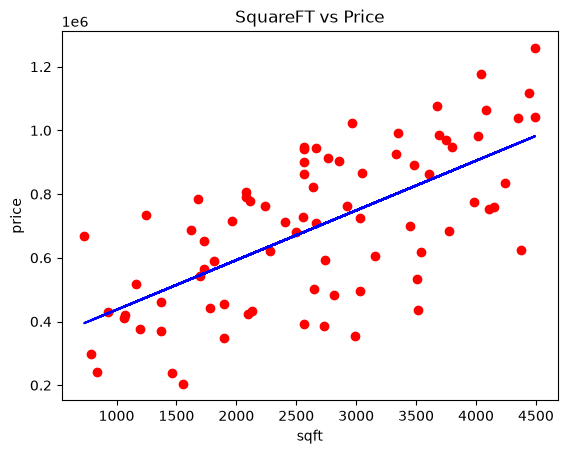

In [113]:
# Visualize the Training dataset

plt.scatter(X_train,y_train,color="red")
plt.plot(X_train,regressor.predict(X_train),color="blue")
plt.title("SquareFT vs Price")
plt.xlabel("sqft")
plt.ylabel("price")
plt.show()

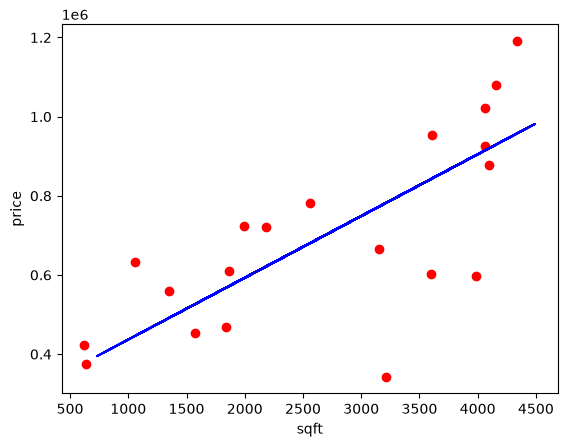

In [114]:
# Visualize the predictions

plt.scatter(X_test,y_test,color="red")
plt.plot(X_train,regressor.predict(X_train),color="blue")
plt.xlabel("sqft")
plt.ylabel("price")
plt.show()

In [119]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.5065826389573176